In [6]:
#opcional (instala pandas seaborn matplotlib scikit-learn numpy, tarda aprox. 3.5 minutos)
%pip install -r requirements.txt

In [8]:
import pandas as pd
import holidays
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import folium
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import  r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# EDA:

Cargamos y visualizamos el dataset.

In [10]:
df = pd.read_csv('content/uber_fares.csv')
df
prueba = df['fare_amount']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


Corroboramos la existencia de nulos y observamos el porcentaje respecto al total para decidir que hacer con ellos.

In [11]:
df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / df.shape[0]) * 100
porcentaje_nulos

key                  0.0000
date                 0.0000
fare_amount          0.0000
pickup_datetime      0.0000
pickup_longitude     0.0000
pickup_latitude      0.0000
dropoff_longitude    0.0005
dropoff_latitude     0.0005
passenger_count      0.0000
dtype: float64

Dado que los nulos encontrados en las variables "dropoff_longitude" y "dropoff_latitude" equivalen a un 0.0005% de los datos del dataset, decidimos eliminar sus filas correspondientes para simplificar el preprocesamiento sin afectar el análisis.

In [12]:
df = df.dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 199999 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                199999 non-null  int64  
 1   date               199999 non-null  str    
 2   fare_amount        199999 non-null  float64
 3   pickup_datetime    199999 non-null  str    
 4   pickup_longitude   199999 non-null  float64
 5   pickup_latitude    199999 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    199999 non-null  int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 15.3 MB


También detectamos que tanto la variable "pickup_datetime" y "date" son de tipo Object, para una mejor manipulacion de datos las transformamos en tipo datetime.

In [13]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.DataFrame'>
Index: 199999 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                199999 non-null  int64              
 1   date               199999 non-null  datetime64[us]     
 2   fare_amount        199999 non-null  float64            
 3   pickup_datetime    199999 non-null  datetime64[us, UTC]
 4   pickup_longitude   199999 non-null  float64            
 5   pickup_latitude    199999 non-null  float64            
 6   dropoff_longitude  199999 non-null  float64            
 7   dropoff_latitude   199999 non-null  float64            
 8   passenger_count    199999 non-null  int64              
dtypes: datetime64[us, UTC](1), datetime64[us](1), float64(5), int64(2)
memory usage: 15.3 MB


Observamos que lo único en lo que difieren los datos de la columna "pickup_datetime" y "date" es en que una muestra la zona horaria. Fuera de eso "date" seria redundante por lo que vamos a comprobar si todas las fechas son iguales y en caso de serlo podriamos eliminar la columna "date".

In [14]:
(df['date'].dt.date == df['pickup_datetime'].dt.date).value_counts()

True    199999
Name: count, dtype: int64

Boxplots

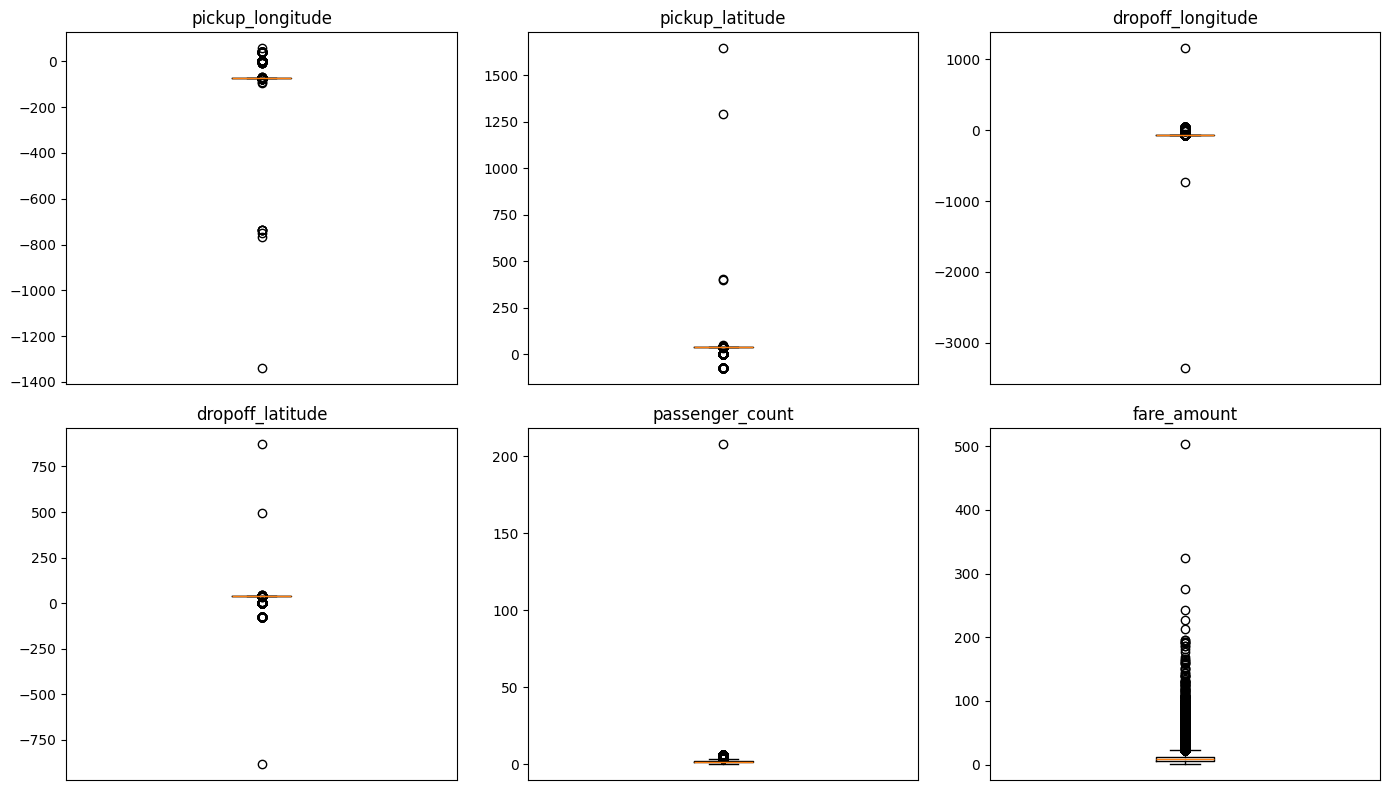

In [15]:
columnas = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'fare_amount']

plt.figure(figsize=(14, 8))
for i, col in enumerate(columnas):
    plt.subplot(2, 3, i+1)
    plt.boxplot(df[col])
    plt.title(col)
    plt.xticks([])
plt.tight_layout()
plt.show()


Los boxplots muestran outliers en casi todas las variables a excepción de passenger_count, los trataremos en los pasos siguientes

Histogramas

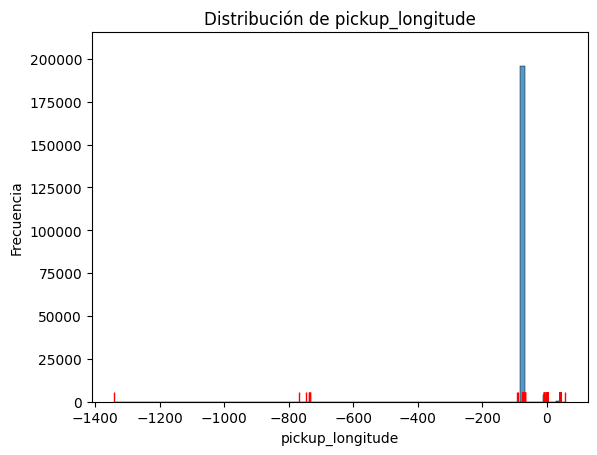

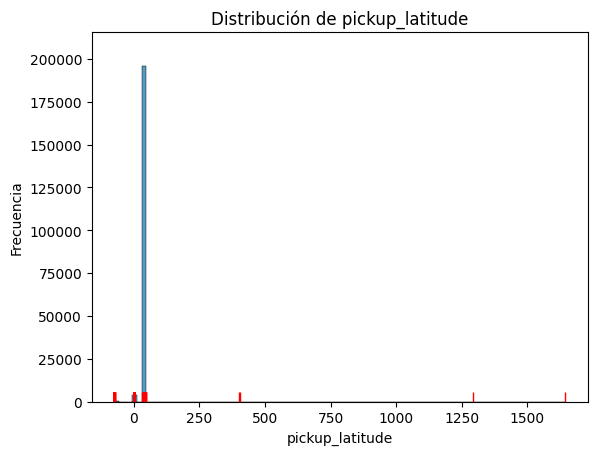

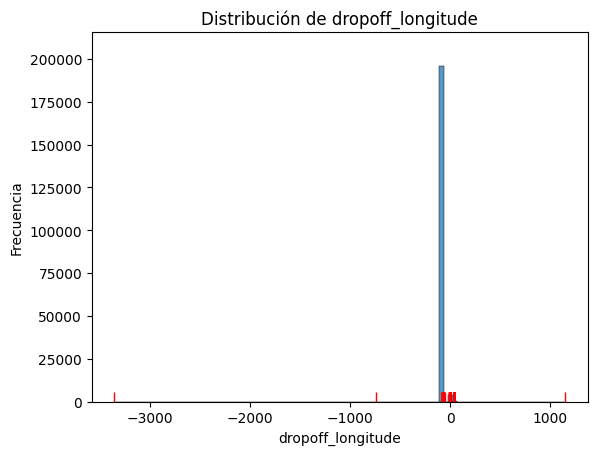

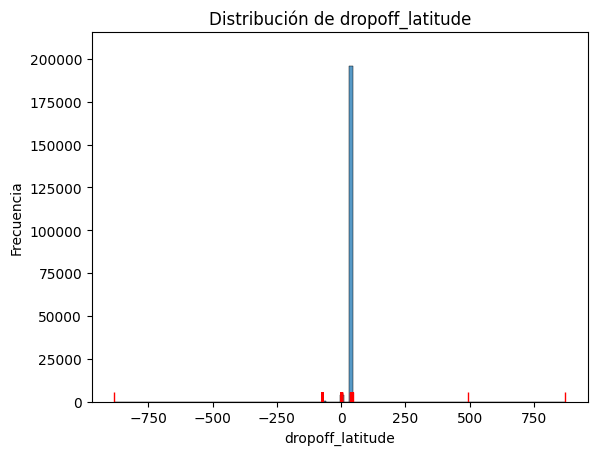

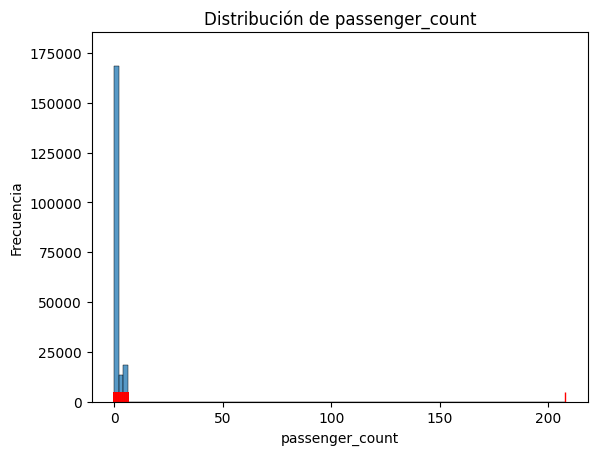

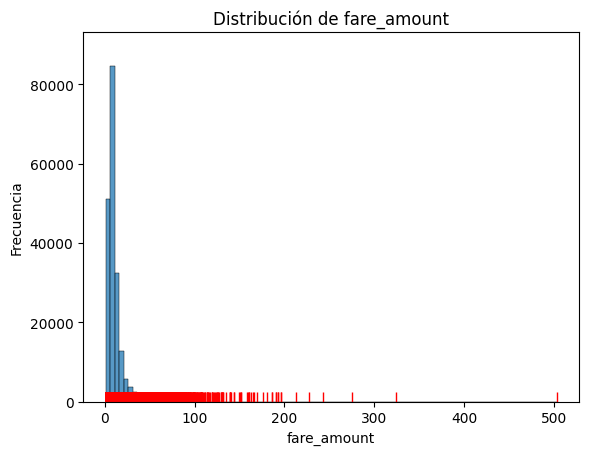

In [16]:
columnas = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'fare_amount']

for columna in columnas:
    sns.histplot(df[columna], bins=100)
    sns.rugplot(df[columna], color='red') # -> con rugplot visualizamos valores individuales en el histograma
    plt.title(f'Distribución de {columna}')
    plt.xlabel(columna)
    plt.ylabel('Frecuencia')
    plt.show()

Notamos que hay precios atípicos en las tarifas, valores muy bajos como 0, o muy altos como 500, por lo que conviene eliminarlos

In [17]:
y = df['fare_amount']

In [18]:
#eliminamos los valores atípicos
# Usámos el método de los cuartiles, marcamos como outliers los valores superiores a Q3 + 1,5 × RI o inferiores a Q1 - 1,5 × RI

len1 = len(df)
Q1 = y.quantile(0.25) # cuantil 0.25 (busca el valor donde la probabilidad acumulada es del 25%)
Q3 = y.quantile(0.75) # cuantil 0.75 ('' el 75% de las tarifas son menores a este valor)
RI = Q3 - Q1       # rango intercuartílico

limite_inf = Q1 - 1.5 * RI
limite_sup = Q3 + 1.5 * RI

#corta por encima y por debajo de los límites
df = df[(y >= limite_inf) & (y <= limite_sup)]
df.info()
len2 = len(df)
print(len1 - len2)

<class 'pandas.DataFrame'>
Index: 183350 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                183350 non-null  int64              
 1   date               183350 non-null  datetime64[us]     
 2   fare_amount        183350 non-null  float64            
 3   pickup_datetime    183350 non-null  datetime64[us, UTC]
 4   pickup_longitude   183350 non-null  float64            
 5   pickup_latitude    183350 non-null  float64            
 6   dropoff_longitude  183350 non-null  float64            
 7   dropoff_latitude   183350 non-null  float64            
 8   passenger_count    183350 non-null  int64              
dtypes: datetime64[us, UTC](1), datetime64[us](1), float64(5), int64(2)
memory usage: 14.0 MB
16649


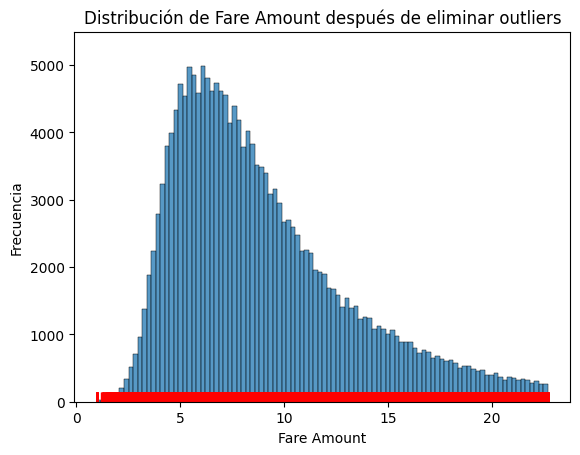

In [ ]:
#visualizacion de fare_amount luego de eliminar outliers
sns.histplot(df['fare_amount'], bins=100)
sns.rugplot(df['fare_amount'], color='red') 
plt.title('Distribución de Fare Amount después de eliminar outliers')
plt.xlabel('Fare Amount')
plt.ylabel('Frecuencia')
plt.show()

Vemos que ahora no aparecen valores atípicos y que los precios de las tarifas son razonables, aproximadamente entre 1 y 22 dólares

In [22]:
df.columns

Index(['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='str')

In [23]:
x=df[['key', 'date', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count']]

Ubicaciones:

In [24]:
#Centro aprox de Nueva York
centro = [40.7128, -74.0060]

m = folium.Map(location=centro, zoom_start=11)

sample_df = df.sample(2000, random_state=42)

for _, row in sample_df.iterrows():
    folium.CircleMarker(
        location=[row["pickup_latitude"], row["pickup_longitude"]],
        radius=1,
        color="blue",
        fill=True,
        fill_opacity=0.5
    ).add_to(m)

    folium.CircleMarker(
        location=[row["dropoff_latitude"], row["dropoff_longitude"]],
        radius=1,
        color="red",
        fill=True,
        fill_opacity=0.5
    ).add_to(m)


# Círculo de 50 km
folium.Circle(
    location=centro,
    radius=50000,  # metros
    color="green",
    fill=True,
    fill_opacity=0.08,
    popup="Radio de 50 km"
).add_to(m)

# Círculo de 100 km
folium.Circle(
    location=centro,
    radius=100000,  # metros
    color="orange",
    fill=True,
    fill_opacity=0.05,
    popup="Radio 100 Km"
).add_to(m)

La mayoria de los puntos tanto de Inicio como de destino se encuentran en Nueva York y alrededores, algunos estan en puntos muy alejados, si bien los viajes a otros estados dentro de USA podrian ser posibles parecen poco probables sobre todo tomando en cuenta el rango de las tarifas por lo que los puntos muy alejados los vamos a sacar y despeus imputaremos su distancia utilizando algun metodo con los puntos restantes.

Vemos aca que la mayoria de lo viajes empiezan y terminan en un radio menor a 50km respecto al centro de Nueva York por lo que vamos a considerar al resto de puntos como errores siendo que no es comun tomar viajes de uber tan largos y algunos tienen puntos en lugares sin sentido como en el oceano. El modelo se vera limitado a no poder predecir correctamente para viajes mayores a 50Km pero no es un caso comun.

In [25]:
m

In [26]:
def es_nuevayork(lat, lon):
    """
    Valida si una coordenada está dentro de los límites de NYC mas
    un radio de 50 km para viajes por fuera.
    """
    return (40.2 <= lat <= 41.2) and (-74.6 <= lon <= -73.4)


# Aplico es_coord True: Dentro NYC False:Fuera NYC (Valido Lat, Long)
df["pickup_en_ny"] = df.apply(lambda row: es_nuevayork(row["pickup_latitude"], row["pickup_longitude"]), axis=1)
df["dropoff_en_ny"] = df.apply(lambda row: es_nuevayork(row["dropoff_latitude"], row["dropoff_longitude"]), axis=1)

#  Valido punto de partida y llegada dentro de la zona definida.
df["viaje_en_ny"] = df["pickup_en_ny"] & df["dropoff_en_ny"]
df.describe()
df['viaje_en_ny'].value_counts()

viaje_en_ny
True     179474
False      3876
Name: count, dtype: int64

Hay aproximadamente 4000 viajes cuyo inicio o final no estan dentro del radio aproximado de 50Km respecto al centro de Manhattan

In [27]:
df["pickup_en_ny"].value_counts()

pickup_en_ny
True     179656
False      3694
Name: count, dtype: int64

In [28]:
df["dropoff_en_ny"].value_counts()

dropoff_en_ny
True     179687
False      3663
Name: count, dtype: int64

In [29]:
#Reemplazamos las coordenadas fuera de zona por valores NULOS para luego imputarlos con algun método.
df.loc[~df["pickup_en_ny"], ["pickup_latitude", "pickup_longitude"]] = np.nan
df.loc[~df["dropoff_en_ny"], ["dropoff_latitude", "dropoff_longitude"]] = np.nan

In [30]:
df['dropoff_en_ny'].value_counts()

dropoff_en_ny
True     179687
False      3663
Name: count, dtype: int64

In [31]:

nulos_por_columna = df.isnull().sum()

print(nulos_por_columna)

key                     0
date                    0
fare_amount             0
pickup_datetime         0
pickup_longitude     3694
pickup_latitude      3694
dropoff_longitude    3663
dropoff_latitude     3663
passenger_count         0
pickup_en_ny            0
dropoff_en_ny           0
viaje_en_ny             0
dtype: int64


In [32]:
df.shape

(183350, 12)

In [33]:
df2 = df.copy()

In [34]:
df2["passenger_count"].value_counts()

passenger_count
1      127182
2       26756
5       12843
3        8130
4        3899
6        3863
0         676
208         1
Name: count, dtype: int64

In [48]:
# Uber Envio (0 pasajeros) y UberXL para viajes de grupos de hasta 5 o 6 personas.
#Por lo que el valor atipico en cantidad de pasajeros seria el de 208 lo vamos a tomar como el maximo valor posible (podriamos eliminarlo ya que es 1 solo)
df2.loc[(df2['passenger_count'] > 6) , 'passenger_count'] = 6
df2["passenger_count"].value_counts()

passenger_count
1    127182
2     26756
5     12843
3      8130
4      3899
6      3864
0       676
Name: count, dtype: int64

In [36]:
def categoria_uber(df_uber):
    condiciones = [
        df_uber["passenger_count"] == 0,
        df_uber["passenger_count"].between(1, 4),
        df_uber["passenger_count"].between(5, 6)
    ]

    valores = ["Uber Envio", "Uber X", "Uber XL"]

    df_uber["categoria_uber"] = np.select(condiciones, valores, default="Error")
    return df_uber

In [37]:
df2 = categoria_uber(df2)

In [38]:
df2["categoria_uber"].value_counts()

categoria_uber
Uber X        165967
Uber XL        16707
Uber Envio       676
Name: count, dtype: int64

In [39]:
#Extraemos el dia de la semana Monday = 0 Sunday = 6 (documentacion pandas)
df2['date'] = pd.to_datetime(df2['date'])
df2['dia_de_la_semana'] = df2['date'].dt.weekday
df2['dia_de_la_semana'].value_counts()

dia_de_la_semana
4    28398
5    28094
3    27440
2    26665
1    25940
6    23902
0    22911
Name: count, dtype: int64

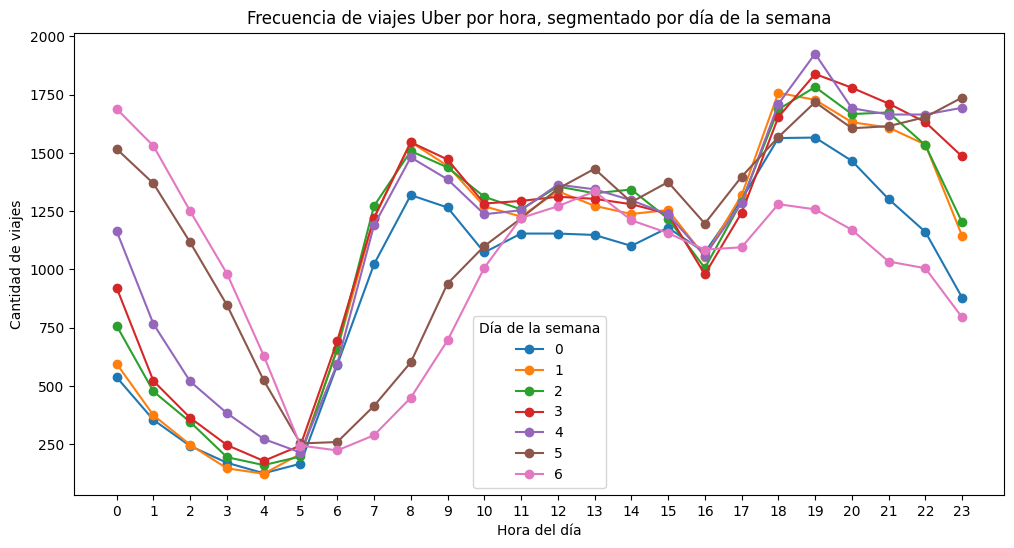

In [40]:
df2["hour"] = pd.to_datetime(df2["pickup_datetime"]).dt.hour

conteo = df2.groupby(["dia_de_la_semana", "hour"]).size().reset_index(name="viajes")


plt.figure(figsize=(12,6))
for dia in conteo["dia_de_la_semana"].unique():
    subset = conteo[conteo["dia_de_la_semana"] == dia]
    plt.plot(subset["hour"], subset["viajes"], marker="o", label=dia)

plt.xlabel("Hora del día")
plt.ylabel("Cantidad de viajes")
plt.title("Frecuencia de viajes Uber por hora, segmentado por día de la semana")
plt.xticks(range(24))
plt.legend(title="Día de la semana")
plt.show()

In [41]:
df2['pickup_datetime'] = df2['date'].dt.hour
df2
def franja(hora):
  if(0 <= hora <6):
    return 'Madrugada'
  elif(6<= hora <12):
    return 'Mañana'
  elif(12<= hora <18):
    return 'Tarde'
  elif(18<= hora <= 23):
    return 'Noche'

df2['franja_horaria'] = df2['pickup_datetime'].apply(franja)
df2['franja_horaria'].value_counts()

franja_horaria
Noche        63785
Tarde        52102
Mañana       44304
Madrugada    23159
Name: count, dtype: int64

In [42]:
us_holidays = holidays.US(years=df2["date"].dt.year.unique())
df2["Feriado"] = df2["date"].dt.date.isin(us_holidays)
df2["Feriado"].value_counts()

Feriado
False    179267
True       4083
Name: count, dtype: int64

In [43]:
#Por logica pensamos que a fin de mes la gente podria tomar menos uber por lo que por la menor demanda podrian ser mas baratos los viajes
def semana_del_mes(dt):
    dia = dt.day
    if 1 <= dia <= 7:
        return 1
    elif 8 <= dia <= 15:
        return 2
    elif 16 <= dia <= 23:
        return 3
    else:
        return 4

df2["week_of_month"] = df2["date"].apply(semana_del_mes)
df2["week_of_month"] .value_counts()


week_of_month
3    49610
2    49495
4    43250
1    40995
Name: count, dtype: int64

In [44]:
def division_distritos_NY(lat, lon):
    # Diccionario con rangos aproximados de cada distrito (lat_min, lat_max, lon_min, lon_max)
    barrios = {
        "Manhattan":   (40.7000, 40.8800, -74.0200, -73.9300),
        "Brooklyn":    (40.5700, 40.7400, -74.0500, -73.8500),
        "Queens":      (40.5400, 40.8000, -73.9600, -73.7000),
        "Bronx":       (40.7900, 40.9200, -73.9300, -73.7600),
        "Staten Island": (40.4800, 40.6500, -74.2500, -74.0500),
    }

    for barrio, (lat_min, lat_max, lon_min, lon_max) in barrios.items():
        if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
            return barrio
    return "Fuera de NYC"
df2["barrio"] = df2.apply(
    lambda row: division_distritos_NY(row["pickup_latitude"], row["pickup_longitude"]),
    axis=1
)
# Verificar resultado
print(df2[["pickup_latitude", "pickup_longitude", "barrio"]].head(30))
df2['barrio'].value_counts()

    pickup_latitude  pickup_longitude        barrio
0         40.738354        -73.999817     Manhattan
1         40.728225        -73.994355     Manhattan
2         40.740770        -74.005043     Manhattan
3         40.790844        -73.976124     Manhattan
4         40.744085        -73.925023        Queens
5         40.755910        -73.969019     Manhattan
7               NaN               NaN  Fuera de NYC
8         40.745767        -73.975187     Manhattan
9         40.741787        -74.001065     Manhattan
10        40.746952        -73.974388     Manhattan
11              NaN               NaN  Fuera de NYC
12        40.804440        -73.966378     Manhattan
13        40.767382        -73.953352     Manhattan
14        40.755193        -73.973370     Manhattan
15        40.751920        -73.990718     Manhattan
16        40.756982        -73.988908     Manhattan
17        40.741138        -74.005665     Manhattan
18        40.767189        -73.962532     Manhattan
19        40

barrio
Manhattan        174222
Fuera de NYC       3859
Queens             2570
Brooklyn           2501
Bronx               187
Staten Island        11
Name: count, dtype: int64

In [45]:
df2.info()

<class 'pandas.DataFrame'>
Index: 183350 entries, 0 to 199999
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   key                183350 non-null  int64         
 1   date               183350 non-null  datetime64[us]
 2   fare_amount        183350 non-null  float64       
 3   pickup_datetime    183350 non-null  int32         
 4   pickup_longitude   179656 non-null  float64       
 5   pickup_latitude    179656 non-null  float64       
 6   dropoff_longitude  179687 non-null  float64       
 7   dropoff_latitude   179687 non-null  float64       
 8   passenger_count    183350 non-null  int64         
 9   pickup_en_ny       183350 non-null  bool          
 10  dropoff_en_ny      183350 non-null  bool          
 11  viaje_en_ny        183350 non-null  bool          
 12  categoria_uber     183350 non-null  str           
 13  dia_de_la_semana   183350 non-null  int32         
 14  hour

Encoding e Imputaciones

In [46]:
# Imputamos por mediana del barrio y con mediana global los que no se pudieron imputar por grupo
for col in ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']:
    mediana_por_barrio = df2.groupby('barrio')[col].transform('median')
    mediana_global = df2[col].median()
    df2[col] = df2[col].fillna(mediana_por_barrio).fillna(mediana_global)

from sklearn.preprocessing import OneHotEncoder
# seleccionamos las columnas categorica y seleccionamos onehotencoder
categoricas = df2[['categoria_uber', 'barrio', 'franja_horaria']]
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(categoricas)

df_encoded= pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['categoria_uber', 'barrio', 'franja_horaria']), index=df2.index)
df2 = pd.concat([df2, df_encoded], axis=1)

# eliminamos columnas categoricas
df2.drop(['categoria_uber', 'barrio', 'franja_horaria'], axis=1, inplace=True)

Scatterplots (gráficos de dispersiones)

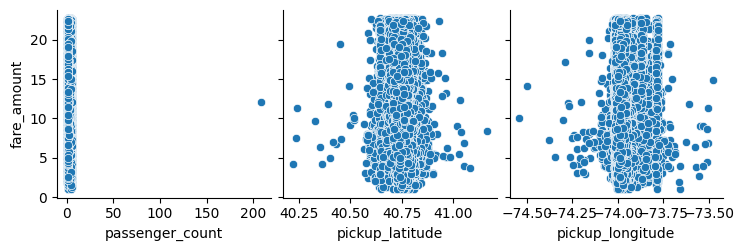

In [ ]:
# Luego de las imputaciones que restaban realizar sobre las variables, podemos graficar los scatterplots entrada vs salida

import matplotlib.pyplot as plt
import seaborn as sns

columnas_sp = ['passenger_count', 'pickup_latitude', 'pickup_longitude']

sns.pairplot(df, x_vars=columnas_sp, y_vars='fare_amount')
plt.show()

Los scatterplots no muestran una relación lineal clara entre las variables de entrada y fare_amount, el modelo lineal puede tener limitaciones para representar la variabilidad de las tarifas sin calcular previamente la distancia del viaje.


Selección de features

In [52]:
def haversine(lat1, lon1, lat2, lon2):
    """
    Calcula la distancia entre dos puntos geográficos (en km)
    usando la fórmula de Haversine.
    """
    R = 6371  #radio de la Tierra en km

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

# crear nueva columna distancia
df2["distancia"] = haversine(
    df2["pickup_latitude"],
    df2["pickup_longitude"],
    df2["dropoff_latitude"],
    df2["dropoff_longitude"]
)

# ver cómo quedó
df2["distancia"].describe()

,distancia
count,183350.000000
mean,2.578658
std,1.907813
min,0.000000
25%,1.216559
50%,2.033440
75%,3.450304
max,53.501532


In [53]:
# Descartamos las columnas que no sean features
X = df2.drop(['fare_amount', 'key', 'date', 'pickup_datetime'], axis=1)
y = df2['fare_amount']

print(f"Features: {X.columns.tolist()}")

Features: ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'pickup_en_ny', 'dropoff_en_ny', 'viaje_en_ny', 'dia_de_la_semana', 'hour', 'Feriado', 'week_of_month', 'categoria_uber_Uber X', 'categoria_uber_Uber XL', 'barrio_Brooklyn', 'barrio_Fuera de NYC', 'barrio_Manhattan', 'barrio_Queens', 'barrio_Staten Island', 'franja_horaria_Mañana', 'franja_horaria_Noche', 'franja_horaria_Tarde', 'distancia']


Escalado y train-test

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# X: matriz de características (FEATURES)
# y: vector de etiquetas (TARGET)

# Dividimos el dataset en entrenamiento y prueba antes de escalar y construimos el pipeline
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# El StandardScaler ya se incluye dentro del pipeline
# y el escalado se ajusta solo con datos de entrenamiento (evita pérdida de información)
modelo = make_pipeline(StandardScaler(), LinearRegression())

# entrenar un modelo
modelo.fit(X_train, y_train)

# hacer predicciones con el conjunto de prueba
y_pred = modelo.predict(X_test)

In [55]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# predicción en TRAIN
y_train_pred = modelo.predict(X_train)

print("TRAIN:")
print("R2:", r2_score(y_train, y_train_pred))
print("MSE:", mean_squared_error(y_train, y_train_pred))
print("MAE:", mean_absolute_error(y_train, y_train_pred))

print("\nTEST:")
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

TRAIN:
R2: 0.6202904298966078
MSE: 6.809640576568494
MAE: 1.833467263018656

TEST:
R2: 0.5946092397677567
MSE: 7.358622319842377
MAE: 1.8576668936927276


El modelo de regresión lineal múltiple no presenta señales claras de overfitting, ya que las métricas obtenidas sobre entrenamiento y prueba son muy similares. Sin embargo, el desempeño general es bajo, especialmente por el valor de R², que es cercano a 0. Esto indica que el modelo explica una porción muy pequeña de la variabilidad de la tarifa, por lo que el fitting conseguido no puede considerarse bueno.

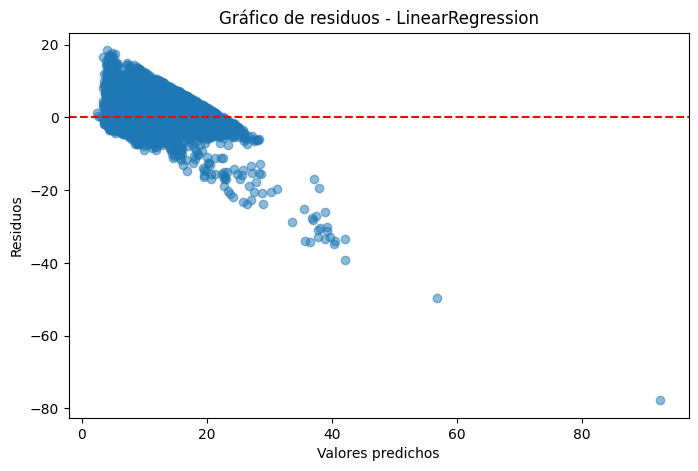

In [56]:
residuos = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuos, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Gráfico de residuos - LinearRegression")
plt.show()

El gráfico de residuos no presenta una distribución aleatoria, sino que evidencia una estructura, sto sugiere que el modelo no logra capturar correctamente la relación entre las variables, además de presentar heterocedasticidad. Por lo tanto, el ajuste del modelo no puede considerarse adecuado.

In [57]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
def evaluar(nombre, modelo, X_train, X_test, y_train, y_test):
    modelo.fit(X_train, y_train)

    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)

    return {
        "Modelo": nombre,
        "modelo_obj": modelo,
        "R2_train": r2_score(y_train, y_train_pred),
        "MSE_train": mean_squared_error(y_train, y_train_pred),
        "RMSE_train": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "MAE_train": mean_absolute_error(y_train, y_train_pred),
        "R2_test": r2_score(y_test, y_test_pred),
        "MSE_test": mean_squared_error(y_test, y_test_pred),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "MAE_test": mean_absolute_error(y_test, y_test_pred),
        "y_test_pred": y_test_pred
    }

In [58]:
modelos = [
    ("LinearRegression", make_pipeline(StandardScaler(), LinearRegression())),
    ("Ridge_0.1", make_pipeline(StandardScaler(), Ridge(alpha=0.1))),
    ("Ridge_1", make_pipeline(StandardScaler(), Ridge(alpha=1))),
    ("Ridge_10", make_pipeline(StandardScaler(), Ridge(alpha=10))),
    ("Lasso_0.001", make_pipeline(StandardScaler(), Lasso(alpha=0.001, max_iter=10000))),
    ("Lasso_0.01", make_pipeline(StandardScaler(), Lasso(alpha=0.01, max_iter=10000))),
    ("ElasticNet_0.001_0.5", make_pipeline(StandardScaler(), ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000))),
    ("ElasticNet_0.01_0.5", make_pipeline(StandardScaler(), ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000))),
]

resultados = []

for nombre, modelo in modelos:
    resultados.append(evaluar(nombre, modelo, X_train, X_test, y_train, y_test))

df_resultados = pd.DataFrame(resultados).drop(columns=["modelo_obj", "y_test_pred"])
df_resultados = df_resultados.sort_values(by="RMSE_test")

df_resultados

,Modelo,R2_train,MSE_train,RMSE_train,MAE_train,R2_test,MSE_test,RMSE_test,MAE_test
6,ElasticNet_0.001_0.5,0.620271,6.809981,2.609594,1.833849,0.594618,7.358469,2.712650,1.858022
3,Ridge_10,0.620290,6.809641,2.609529,1.833501,0.594613,7.358562,2.712667,1.857699
2,Ridge_1,0.620290,6.809641,2.609529,1.833471,0.594610,7.358616,2.712677,1.857670
1,Ridge_0.1,0.620290,6.809641,2.609529,1.833468,0.594609,7.358622,2.712678,1.857667
0,LinearRegression,0.620290,6.809641,2.609529,1.833467,0.594609,7.358622,2.712678,1.857667
4,Lasso_0.001,0.620247,6.810422,2.609678,1.833736,0.594583,7.359094,2.712765,1.857868
7,ElasticNet_0.01_0.5,0.619625,6.821579,2.611815,1.838010,0.594242,7.365284,2.713906,1.861722
5,Lasso_0.01,0.619052,6.831855,2.613782,1.837286,0.593310,7.382206,2.717022,1.860925


Mejor modelo:
ElasticNet_0.001_0.5
R2 test: 0.5946176857471508
MSE test: 7.358469009065275
RMSE test: 2.7126498132020793
MAE test: 1.8580224014991997


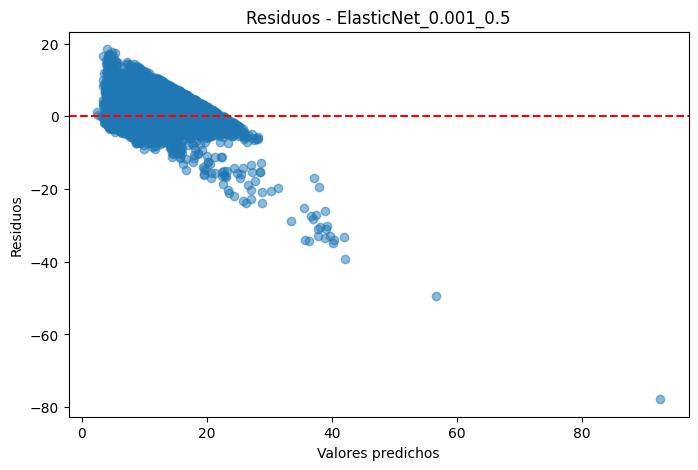

In [59]:
mejor = sorted(resultados, key=lambda x: x["RMSE_test"])[0]

print("Mejor modelo:")
print(mejor["Modelo"])
print("R2 test:", mejor["R2_test"])
print("MSE test:", mejor["MSE_test"])
print("RMSE test:", mejor["RMSE_test"])
print("MAE test:", mejor["MAE_test"])

residuos = y_test - mejor["y_test_pred"]

plt.figure(figsize=(8,5))
plt.scatter(mejor["y_test_pred"], residuos, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title(f"Residuos - {mejor['Modelo']}")
plt.show()

Gradiente descendiente

In [64]:
from sklearn.linear_model import SGDRegressor
# modelo con gradiente descendente
modelo_sgd = make_pipeline(
    StandardScaler(),
    SGDRegressor(
        max_iter=5000,
        tol=1e-4,
        eta0=0.0001,
        learning_rate='adaptive',
        penalty=None,
        random_state=42
    )
)

modelo_sgd.fit(X_train, y_train)

y_train_pred_sgd = modelo_sgd.predict(X_train)
y_test_pred_sgd = modelo_sgd.predict(X_test)

In [65]:
print("SGD - TRAIN:")
print("R2:", r2_score(y_train, y_train_pred_sgd))
print("MSE:", mean_squared_error(y_train, y_train_pred_sgd))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred_sgd)))
print("MAE:", mean_absolute_error(y_train, y_train_pred_sgd))

print("\nSGD - TEST:")
print("R2:", r2_score(y_test, y_test_pred_sgd))
print("MSE:", mean_squared_error(y_test, y_test_pred_sgd))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred_sgd)))
print("MAE:", mean_absolute_error(y_test, y_test_pred_sgd))

SGD - TRAIN:
R2: 0.6202788116791844
MSE: 6.80984893551181
RMSE: 2.6095687259606346
MAE: 1.8335194226594835

SGD - TEST:
R2: 0.5946150723571999
MSE: 7.3585164471213655
RMSE: 2.712658557047194
MAE: 1.8576443366382316


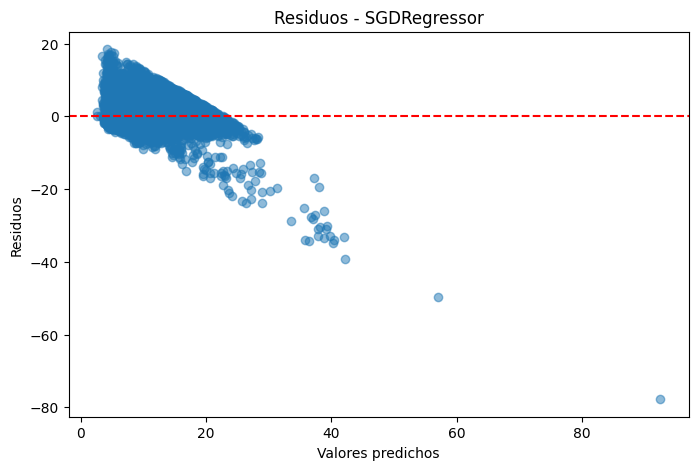

In [66]:
residuos = y_test - y_test_pred_sgd

plt.figure(figsize=(8,5))
plt.scatter(y_test_pred_sgd, residuos, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos - SGDRegressor")
plt.show()

También probamos un modelo de regresión lineal usando SGDRegressor, que ajusta los coeficientes con gradiente descendente en lugar de calcularlos directamente como hace LinearRegression. Al principio tuvimos problemas porque el modelo no convergía bien, pero ajustando los hiperparámetros (como el learning rate) se logró un comportamiento estable. Una vez corregido eso, los resultados fueron muy parecidos a los obtenidos con los otros modelos lineales (LinearRegression, Ridge y ElasticNet). Esto es esperable, ya que todos están resolviendo básicamente el mismo problema y la diferencia principal está en cómo encuentran la solución.

In [67]:
"""El gráfico de residuos del modelo con gradiente descendente es bastante similar al de los otros modelos.
 Si bien los resultados mejoraron mucho después de agregar la variable distancia, todavía se nota cierta forma en los residuos,
 lo que indica que el modelo no captura perfectamente la relación entre las variables."""

'El gráfico de residuos del modelo con gradiente descendente es bastante similar al de los otros modelos.\n Si bien los resultados mejoraron mucho después de agregar la variable distancia, todavía se nota cierta forma en los residuos,\n lo que indica que el modelo no captura perfectamente la relación entre las variables.'